# Aiyagari (1994)の数値計算

[「定量的マクロ経済学と数値計算」のサポートページにあるJuliaコード](https://github.com/quant-macro-book/chapter5/tree/master/Julia)を使って、Aiyagari (1994)の数値計算のステップを説明する。

## 定常均衡を解く

1. ある利子率 $r_0$ のもとで企業の資本需要 $K_0$ と賃金 $w_0$ を求める
2. $r_0$ と $w_0$ を所与として、個人の効用最大化問題を解き政策関数を得る
3. 政策関数をもとに、状態変数の定常分布を求め、総資本供給 $A_0$ を求める
4. $K_0$ と $A_0$ の差が小さければ計算を終了し、そうでなければステップ1で $r_0$ を調整し各ステップを繰り返す

In [37]:
# load functrions made in advance
# include("../quant_macro_book/chapter5/julia/aiyagari_vfi1.jl")
# include("../quant_macro_book/chapter5/julia/aiyagari_vfi2.jl")
# include("../quant_macro_book/chapter5/julia/aiyagari_vfi3.jl")
include("../quant_macro_book/chapter5/julia/tauchen.jl")

# import libraries
using Plots
using Optim
using Random
using Distributions 
using LaTeXStrings
using JLD


In [38]:
# create constructer that contains parameters
struct Model{TI<:Integer, TF<:AbstractFloat}
    
    mu::TF                # risk aversion (=3 baseline)
    beta::TF              # subjective discount factor 
    delta::TF             # depreciation
    alpha::TF             # capital's share of income
    b::TF                 # borrowing limit
    Nl::TI                # number of discretized states
    s::Array{TF,1}        # (exponentialed) discretized states of log labor earnings
    prob::Array{TF,2}     # transition matrix of the Markov chain
    labor::TF             # aggregate labor supply

    Nk::TI                # grid size for capital (state variable)
    maxK::TF              # maximum value of capital grid
    curvK::TF             # a parameter controlling grid width

    Nk2::TI               # grid size for capital (control variable)

    NT::TI                # transition period

end

In [39]:
# ===================== #
#  SET PARAMETER VALUES #
# ===================== #

mu    = 3.0;             # risk aversion (=3 baseline)             
beta  = 0.96;            # subjective discount factor 
delta = 0.08;            # depreciation
alpha = 0.36;            # capital's share of income
b     = 3.0;             # borrowing limit

Nk = 300;
maxK = 30.0;
curvK = 2.0;
Nk2 = 800;

NT = 200;

In [40]:
# ================================================= #
#  COMPUTE TRANSITION MATRIX OF LABOR PRODUCTIVITY  #
# ================================================= #

# ROUTINE tauchen.m TO COMPUTE TRANSITION MATRIX, GRID OF AN AR(1) AND
# STATIONARY DISTRIBUTION
# approximate labor endowment shocks with seven states Markov chain
# log(s_{t}) = rho*log(s_{t-1})+e_{t} 
# e_{t}~ N(0,sig^2)

Nl  = 7;             # number of discretized states
rho = 0.6;           # first-order autoregressive coefficient
sig = 0.4;           # intermediate value to calculate sigma (=0.4 BASE)

# prob   : transition matrix of the Markov chain
# logs   : the discretized states of log labor earnings
# invdist: the invariant distribution of Markov chain

M = 2.0;
logs,prob,invdist = tauchen(Nl,rho,sig,M);
s = exp.(logs);
labor = s'*invdist;
println(logs)
println(prob)
println(invdist)

[-1.0, -0.6666666666666666, -0.3333333333333333, 0.0, 0.3333333333333333, 0.6666666666666666, 1.0]
[0.27983446359970576 0.31887186208321794 0.2619634268674542 0.11169010115661171 0.024660383057955815 0.002810144610403964 0.00016961862465059152; 0.13933024744962202 0.2619634268674542 0.31887186208321794 0.20154426005488835 0.06606573088977274 0.01120099399075214 0.001023478664292532; 0.0566727546097629 0.16995459776710528 0.30657939947575413 0.2871345789825922 0.13959951230096823 0.03516662026158213 0.004892536602234987; 0.018610425189886332 0.0870393484769689 0.2328113458438344 0.3230777609786207 0.23281134584383445 0.08703934847696893 0.018610425189886315; 0.004892536602234982 0.03516662026158211 0.13959951230096826 0.2871345789825923 0.306579399475754 0.1699545977671052 0.056672754609762954; 0.0010234786642925847 0.011200993990752113 0.0660657308897727 0.20154426005488835 0.31887186208321794 0.2619634268674542 0.13933024744962208; 0.0001696186246506186 0.002810144610403942 0.02466038

In [41]:
# ============================================ #
#  CREATE CONSTRUCTER THAT CONTAINS PARAMETER  #
# ============================================ #

m = Model(mu,beta,delta,alpha,b,Nl,s,prob,labor, Nk, maxK, curvK, Nk2, NT) 

Model{Int64, Float64}(3.0, 0.96, 0.08, 0.36, 3.0, 7, [0.36787944117144233, 0.513417119032592, 0.7165313105737893, 1.0, 1.3956124250860895, 1.9477340410546757, 2.718281828459045], [0.27983446359970576 0.31887186208321794 … 0.002810144610403964 0.00016961862465059152; 0.13933024744962202 0.2619634268674542 … 0.01120099399075214 0.001023478664292532; … ; 0.0010234786642925847 0.011200993990752113 … 0.2619634268674542 0.13933024744962208; 0.0001696186246506186 0.002810144610403942 … 0.31887186208321794 0.27983446359970576], 1.1257073928218677, 300, 30.0, 2.0, 800, 200)

### ステップ1：$r_0$のもとで$K_0$と$w_0$を求める

In [42]:
rate0 = 0.02; # initial guess

In [43]:
function calculate_K0(m, r)
    K0 = m.labor*(m.alpha/(r+m.delta))^(1/(1-m.alpha)); # caputal demand
    return K0
end
K0 = calculate_K0(m, rate0)
println("K0 = ", K0)

function calculate_w0(m, r)
    w0 = (1-m.alpha)*((m.alpha/(r+m.delta))^m.alpha)^(1/(1-m.alpha));
    return w0
end
w0 = calculate_w0(m, rate0)
println("w0 = ", w0)

K0 = 8.33006088438967
w0 = 1.3155281045708864


### ステップ2： 個人の効用最大化から政策関数を求める

1. 資産のグリッドを作る（制御変数の（次期の）資産と状態変数の資産でグリッドの数が違う場合は、前者を後者に変換する関数も用意する）
2. VFIを解いて政策関数を得る（制御変数は離散化されていて、グリッドサーチを使っている）

#### ステップ2.1：資産のグリッドを作る

In [44]:
function generate_capital_grid(m, r=nothing, wage=nothing)

    if (r === nothing) && (wage === nothing) # if these are not specified, use no-borrowing condition
        phi = 0.0;
    else
        # borrowing limit
        if r <= 0.0
            phi = m.b;
        else
            phi = min(m.b,wage*m.s[1]/r);
        end
    end

    # -phi is borrowing limit, b is adhoc
    # the second term is natural limit

    # capital grid (need define in each iteration since it depends on r/phi)
    minK = -phi;                                  # borrowing constraint

    gridk = zeros(m.Nk);
    gridk[1] = minK;
    for kc in 2:m.Nk
        gridk[kc]=gridk[1]+(m.maxK-minK)*((kc-1)/(m.Nk-1))^m.curvK;
    end

    gridk2 = zeros(m.Nk2);
    gridk2[1] = minK;
    for kc in 2:m.Nk2
        gridk2[kc]=gridk2[1]+(m.maxK-minK)*((kc-1)/(m.Nk2-1))^m.curvK;
    end

    return gridk, gridk2
end
grids = generate_capital_grid(m, rate0, w0);

In [45]:
function translate_capital_grid(m, grids)

    gridk, gridk2 = grids

    # =================================================== #
    #  SPLIT GRID in gridk2 TO NEARBY TWO GRIDS IN gridk  #
    # =================================================== #
    
    # calculate node and weight for interpolation  
    kc1vec=zeros(m.Nk2);
    kc2vec=zeros(m.Nk2);

    prk1vec=zeros(m.Nk2);
    prk2vec=zeros(m.Nk2);

    for kc in 1:m.Nk2

        xx = gridk2[kc];

        if xx >= gridk[m.Nk]

            kc1vec[kc] = m.Nk;
            kc2vec[kc] = m.Nk;

            prk1vec[kc] = 1.0;
            prk2vec[kc] = 0.0;

        else

            ind = 1;
            while xx > gridk[ind+1]
                ind += 1
                if ind+1 >= m.Nk
                    break
                end
            end

            kc1vec[kc] = ind

            if ind < m.Nk

                kc2vec[kc] = ind+1;
                dK=(xx-gridk[ind])/(gridk[ind+1]-gridk[ind]);
                prk1vec[kc] = 1.0-dK;
                prk2vec[kc] = dK;

            else

                kc2vec[kc] = ind;
                prk1vec[kc] = 1.0;
                prk2vec[kc] = 0.0;

            end
        end
    end

    return kc1vec, kc2vec, prk1vec, prk2vec
end
capital_grid_translations = translate_capital_grid(m, grids);

#### ステップ2.2：効用最大化問題をVFIで解き、政策関数を得る

In [46]:
function solve_VFI(m, r0, K0, wage, grids, capital_grid_translations; tau=0)

    # capital grids
    gridk, gridk2 = grids

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations

    # initialize some variables
    kfunG = zeros(m.Nl,m.Nk);    # new index of policy function 
    kfun = similar(kfunG);     # policy function   
    v = zeros(m.Nl,m.Nk);        # old value function
    tv = similar(kfunG);       # new value function
    kfunG_old = zeros(m.Nl,m.Nk) # old policy function 

    err     = 10;   # error between old policy index and new policy index
    maxiter = 2000; # maximum number of iteration 
    iter    = 1;    # iteration counter

    while (err > 0) & (iter < maxiter)

        # tabulate the utility function such that for zero or negative
        # consumption utility remains a large negative number so that
        # such values will never be chosen as utility maximizing

        for kc in 1:m.Nk # k(STATE)
            for lc in 1:m.Nl # l

                kccmax = m.Nk2 # maximum index that satisfies c>0.0 
                vtemp = -1000000 .* ones(m.Nk2); # initizalization

                for kcc in 1:m.Nk2 # k'(CONTROL)

                    # amount of consumption given (k,l,k')
                    cons = m.s[lc]*wage + (1 + r0 * (1 - tau))*gridk[kc] - gridk2[kcc] + tau * r0 * K0;

                    if cons <= 0.0
                        # penalty for c<0.0
                        # once c becomes negative, vtemp will not be updated(=large negative number)
                        kccmax = kcc-1; 
                        break  
                    end

                    util = (cons^(1-mu)) / (1-mu);

                    # interpolation of next period's value function
                    # find node and weight for gridk2 (evaluating gridk2 in gridk) 
                    kcc1 = Int(kc1vec[kcc]);
                    kcc2 = Int(kc2vec[kcc]);
                    
                    vpr = 0.0; # next period's value function given (l,k')
                    for lcc in 1:m.Nl # expectation of next period's value function
                        
                        vpr += m.prob[lc,lcc]*(prk1vec[kcc]*v[lcc,kcc1] + prk2vec[kcc]*v[lcc,kcc2]);
                    
                    end

                    vtemp[kcc] = util + m.beta*vpr;

                end

                # find k' that  solves bellman equation
                t1,t2 = findmax(vtemp[1:kccmax]); # subject to k' achieves c>0
                tv[lc,kc] = t1;
                kfunG[lc,kc] = t2;
                kfun[lc,kc] = gridk2[t2];

            end
        end

        v = copy(tv);
        err = maximum(abs.(kfunG-kfunG_old));
        # println([iter,err])
        #flush(stdout)
        kfunG_old = copy(kfunG);
        iter += 1

    end

    if iter == maxiter
        println("WARNING!! @aiyagari_vfi2.jl VFI: iteration reached max: iter=$iter,e rr=$err")
    end

    return kfun, kfunG, v
end

solve_VFI (generic function with 1 method)

In [47]:
kfun, kfunG, v = solve_VFI(m, rate0, K0, w0, grids, capital_grid_translations);
kfun

7×300 Matrix{Float64}:
 -3.0       -3.0       -3.0       …  27.8873  28.1275  28.2881  28.5299
 -3.0       -3.0       -3.0          28.0473  28.2881  28.4492  28.6916
 -2.92536   -2.92536   -2.92536      28.2881  28.5299  28.6916  28.9349
 -2.73203   -2.73203   -2.73203      28.6107  28.8537  29.0162  29.2608
 -2.37453   -2.37453   -2.37453      29.0976  29.2608  29.5062  29.6704
 -1.78995   -1.78995   -1.78995   …  29.6704  29.835   30.0     30.0
 -0.932334  -0.932334  -0.932334     30.0     30.0     30.0     30.0

### ステップ3：政策関数から状態変数の定常分布を求め、総資本供給を求める

1. 状態変数の定常分布を求める
2. 総資本供給を求める

#### ステップ3.1：状態変数の定常分布を求める

In [48]:
function derive_stationary_distribution(m, r0, kfun, kfunG, wage, grids, capital_grid_translations)

    # capital grids
    gridk, gridk2 = grids

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations
    
    # calculate stationary distribution
    mea0=ones(m.Nl,m.Nk)/(m.Nl*m.Nk); # old distribution
    mea1=zeros(m.Nl,m.Nk); # new distribution
    err=1;
    errTol=0.00001;
    maxiter=2000;
    iter=1;

    while (err > errTol) & (iter < maxiter)

        for kc in 1:m.Nk # k
            for lc in 1:m.Nl # l
                
                kcc = Int(kfunG[lc,kc]); # index of k'(k,l)

                # interpolation of policy function 
                # split to two grids in gridk
                kcc1 = Int(kc1vec[kcc]);
                kcc2 = Int(kc2vec[kcc]);

                for lcc in 1:m.Nl # l'

                    mea1[lcc,kcc1] += m.prob[lc,lcc]*prk1vec[kcc]*mea0[lc,kc]
                    mea1[lcc,kcc2] += m.prob[lc,lcc]*prk2vec[kcc]*mea0[lc,kc]
                    
                end
            end
        end

        err = maximum(abs.(mea1-mea0));
        mea0 = copy(mea1);
        iter += 1;
        mea1 = zeros(m.Nl,m.Nk);

    end

    if iter == maxiter
        println("WARNING!! @aiyagari_vfi2.jl INVARIANT DIST: iteration reached max: iter=$iter, err=$err")
    end

    return mea0
end
mea0 = derive_stationary_distribution(m, rate0, kfun, kfunG, w0, grids, capital_grid_translations)

7×300 Matrix{Float64}:
 0.000464406  6.38266e-6  6.67031e-7  …  4.25644e-8  2.9365e-8   1.77499e-8
 0.000614971  1.20004e-5  1.25413e-6     3.24079e-7  2.32653e-7  2.12326e-7
 0.000591385  1.46074e-5  1.52657e-6     1.4037e-6   1.05939e-6  1.40553e-6
 0.000306663  9.23265e-6  9.64875e-7     3.3103e-6   2.65539e-6  4.97853e-6
 8.56355e-5   3.02644e-6  3.16284e-7     4.35842e-6  3.73557e-6  9.49192e-6
 1.28112e-5   5.13113e-7  5.36237e-8  …  3.28236e-6  2.99049e-6  9.76181e-6
 1.06204e-6   4.68851e-8  4.89981e-9     1.84972e-6  1.77374e-6  7.28048e-6

#### ステップ3.2：総資本供給を求める

In [49]:
function calculate_capital_supply(mea0, kfun)
    return sum(sum(mea0 .* kfun))
end
K1 = calculate_capital_supply(mea0, kfun)

4.1941393013858965

### ステップ4：資本の需要と供給を比べ、差が大きければ $r_0$ を調節する

ここでは、需要が供給より小さい限り利子率を少しずつ上げていき、需要が供給を上回った時点で計算を止める

In [50]:
println("Capital demand: ", K0)
println("Capital supply: ", K1)

Capital demand: 8.33006088438967
Capital supply: 4.1941393013858965


In [51]:
function solve_stationary_equilibrium(m; tau=0, adj=0.001, rate0=0.02)

    # Pre-declare everything you want to survive the loop
    K0   = 0.0
    K1   = 0.0
    w0   = 0.0
    mea0 = zeros(m.Nl, m.Nk)
    v = zeros(m.Nl, m.Nk)
    grid1 = zeros(m.Nk)

    while true
        # step 1
        K0 = calculate_K0(m, rate0)
        w0 = calculate_w0(m, rate0)

        # step 2
        grids = generate_capital_grid(m, rate0, w0);
        grid1 = grids[1]
        capital_grid_translations = translate_capital_grid(m, grids);

        # step 3
        kfun, kfunG, v = solve_VFI(m, rate0, K0, w0, grids, capital_grid_translations; tau=tau);

        # step 4
        mea0 = derive_stationary_distribution(m, rate0, kfun, kfunG, w0, grids, capital_grid_translations)
        K1 = calculate_capital_supply(mea0, kfun)

        println(
            "r0: ", round(rate0, digits=4), 
            ", K0: ", round(K0, digits=3), 
            ", K1: ", round(K1, digits=3),
            )

        # stop if capital demand < capital supply
        K0 < K1 && break

        rate0 += adj

    end

    return (; rate0, K1, w0, mea0, grid1, v)

end

solve_stationary_equilibrium (generic function with 1 method)

In [88]:
res = solve_stationary_equilibrium(m; adj=0.0001, rate0=0.026);

r0: 0.026, K0: 7.605, K1: 6.419
r0: 0.0261, K0: 7.594, K1: 6.401
r0: 0.0262, K0: 7.583, K1: 6.466
r0: 0.0263, K0: 7.572, K1: 6.53
r0: 0.0264, K0: 7.561, K1: 6.579
r0: 0.0265, K0: 7.549, K1: 6.587
r0: 0.0266, K0: 7.538, K1: 6.676
r0: 0.0267, K0: 7.527, K1: 6.708
r0: 0.0268, K0: 7.516, K1: 6.705
r0: 0.0269, K0: 7.505, K1: 6.778
r0: 0.027, K0: 7.494, K1: 6.798
r0: 0.0271, K0: 7.483, K1: 6.791
r0: 0.0272, K0: 7.473, K1: 6.835
r0: 0.0273, K0: 7.462, K1: 6.889
r0: 0.0274, K0: 7.451, K1: 6.957
r0: 0.0275, K0: 7.44, K1: 7.004
r0: 0.0276, K0: 7.429, K1: 7.03
r0: 0.0277, K0: 7.418, K1: 7.06
r0: 0.0278, K0: 7.408, K1: 7.09
r0: 0.0279, K0: 7.397, K1: 7.124
r0: 0.028, K0: 7.386, K1: 7.189
r0: 0.0281, K0: 7.376, K1: 7.217
r0: 0.0282, K0: 7.365, K1: 7.239
r0: 0.0283, K0: 7.354, K1: 7.268
r0: 0.0284, K0: 7.344, K1: 7.283
r0: 0.0285, K0: 7.333, K1: 7.335


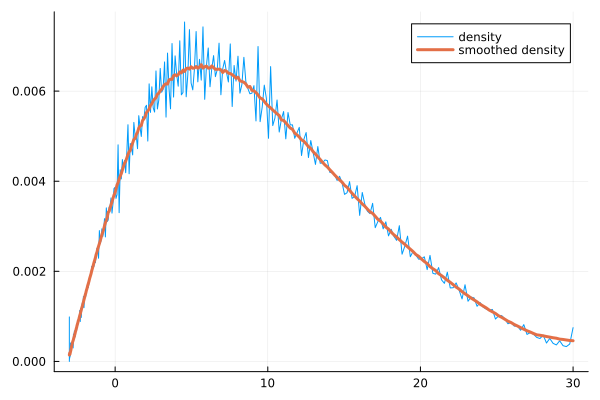

In [89]:
# Moving average smoothing
y = vec(sum(res.mea0, dims=1))
window = 20
y_smooth = [mean(y[max(1,i-window÷2):min(length(y),i+window÷2)]) for i in 1:length(y)]
plot(res.grid1, vec(sum(res.mea0, dims=1)), label="density", linewidth = 1)
plot!(res.grid1, y_smooth, label="smoothed density", linewidth = 3)


### おまけ：総資産供給曲線を求める

In [90]:
function derive_capital_supply_curve(m, r0_grid; tau=0)

    # Pre-declare everything you want to survive the loop
    K0_grid   = zeros(length(r0_grid))
    K1_grid   = zeros(length(r0_grid))

    for (i, rate0) in enumerate(r0_grid)
        # step 1
        K0 = calculate_K0(m, rate0)
        w0 = calculate_w0(m, rate0)

        # step 2
        grids = generate_capital_grid(m, rate0, w0);
        capital_grid_translations = translate_capital_grid(m, grids);

        # step 3
        kfun, kfunG, v = solve_VFI(m, rate0, K0, w0, grids, capital_grid_translations; tau=tau);

        # step 4
        mea0 = derive_stationary_distribution(m, rate0, kfun, kfunG, w0, grids, capital_grid_translations)
        K1 = calculate_capital_supply(mea0, kfun)
        K1_grid[i] = K1

        K0_grid[i] = m.labor*(m.alpha/(rate0+m.delta))^(1/(1-m.alpha)); # caputal demand

    end

    return (; K0_grid, K1_grid)

end

derive_capital_supply_curve (generic function with 1 method)

In [ ]:
r0_grid = 0.026:0.001:0.030
K_grids = derive_capital_supply_curve(m, r0_grid);

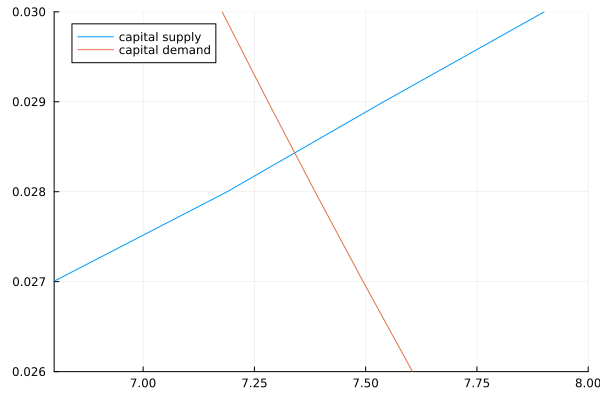

In [93]:
plot(K_grids.K1_grid, r0_grid, label="capital supply")
plot!(K_grids.K0_grid, r0_grid, label="capital demand")
xlims!(6.8, 8)
ylims!(0.026, 0.030)
# plot!([res.K1], [res.rate0], seriestype=:scatter, label="")

## 移行過程を求める

1. 始点（税導入前の定常状態）と終点（税導入後の定常状態）を求める
2. 移行過程での資産需要 $\{K_t\}_{t=0}^T$ を当て推量し、それに基づき利子率 $\{r_t\}_{t=0}^T$ と税収入 $\{\xi_t\}_{t=0}^T$ 求める
3. 終点の価値関数とステップ2の当て推量した流列から、各期での政策関数を求める
4. 求めた政策変数と始点での状態変数の分布から、各期での状態変数の分布を求め、各期での総資産供給を求める
5. 各期で資産の需給が一致するかを確認し、一致しない場合、当て推量した資産需要を更新しステップ3に戻る

元コードに従って、ここでは借入の下限を0とする（つまり借入できないこととする）。

In [96]:
m_transition = Model(
    mu, beta, delta, alpha, 0.0, Nl, s, prob, labor, Nk, maxK, curvK, Nk2, NT
    )

Model{Int64, Float64}(3.0, 0.96, 0.08, 0.36, 0.0, 7, [0.36787944117144233, 0.513417119032592, 0.7165313105737893, 1.0, 1.3956124250860895, 1.9477340410546757, 2.718281828459045], [0.27983446359970576 0.31887186208321794 … 0.002810144610403964 0.00016961862465059152; 0.13933024744962202 0.2619634268674542 … 0.01120099399075214 0.001023478664292532; … ; 0.0010234786642925847 0.011200993990752113 … 0.2619634268674542 0.13933024744962208; 0.0001696186246506186 0.002810144610403942 … 0.31887186208321794 0.27983446359970576], 1.1257073928218677, 300, 30.0, 2.0, 800, 200)

In [97]:
grids = generate_capital_grid(m_transition);
capital_grid_translations = translate_capital_grid(m_transition, grids);

### ステップ1：始点と終点の定常状態を求める

In [126]:
res_SS0 = solve_stationary_equilibrium(m_transition; adj=0.0002, rate0=0.023);

r0: 0.023, K0: 7.954, K1: 7.741
r0: 0.0232, K0: 7.93, K1: 7.791
r0: 0.0234, K0: 7.906, K1: 7.834
r0: 0.0236, K0: 7.882, K1: 7.917


In [127]:
r_SS0 = res_SS0.rate0;
K_SS0 = res_SS0.K1;
T_SS0 = r_SS0 * K_SS0 * 0;
v_SS0 = res_SS0.v;
mea_SS0 = res_SS0.mea0;

In [129]:
tau = 0.1;
res_SS1 = solve_stationary_equilibrium(m_transition; tau=tau, adj=0.0002, rate0=0.025);

r0: 0.025, K0: 7.719, K1: 7.373
r0: 0.0252, K0: 7.696, K1: 7.404
r0: 0.0254, K0: 7.673, K1: 7.428
r0: 0.0256, K0: 7.65, K1: 7.499
r0: 0.0258, K0: 7.628, K1: 7.547
r0: 0.026, K0: 7.605, K1: 7.632


In [130]:
r_SS1 = res_SS1.rate0;
K_SS1 = res_SS1.K1;
T_SS1 = r_SS1 * K_SS1 * tau;
v_SS1 = res_SS1.v;
mea_SS1 = res_SS1.mea0;

### ステップ2：移行過程での資産需要を当て推量し、それに基づき利子率と税収入を求める

In [131]:
function make_initial_guesses(m, K_SS0, K_SS1)

    # ============================== #
    #  INITIAL GUESS OF KT0 and TT0  #
    # ============================== #

    KT0 = K_SS1 .* ones(m.NT);
    # TT0 = T_SS1 .* ones(m.NT);

    # NT0 = 30; # considering relatively quick convergence to the new steady state
    NT0 = m.NT;

    intK=(K_SS1-K_SS0)/(NT0-1);
    # intT=(T_SS1-T_SS0)/(NT0-1);

    for tc=1:NT0
        KT0[tc] = K_SS0+intK*(tc-1);
        #TT0[tc] = T_SS0+intT*(tc-1);    # let T to jump to final SS value
    end

    # ================================ #
    #  rT0 BASED ON INITIAL GUESS KT0  #
    # ================================ #

    rT0 = zeros(m.NT);

    for tc in 1:m.NT
        rT0[tc] = m.alpha * ((KT0[tc] / m.labor)^(m.alpha - 1)) - m.delta;
    end

    TT0 = KT0 .* rT0 .* tau;

    return TT0, KT0, rT0
end

make_initial_guesses (generic function with 1 method)

In [132]:
TT0, KT0, rT0 = make_initial_guesses(m_transition, K_SS0, K_SS1);

### ステップ3：終点の価値関数とステップ2の当て推量した流列から、各期での政策関数を求める

In [133]:
function compute_value_function_backwards!(
    vfun0, kfunGT, kfunT, m, tc, TT0, KT0, rT0, 
    grids, capital_grid_translations, tau
    )

    # capital grids
    gridk, gridk2 = grids

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations

    r0 = rT0[tc];
    T0 = TT0[tc];
    # wage = (1-m.alpha)*((m.alpha/(r0+m.delta))^m.alpha)^(1/(1-m.alpha));
    wage = calculate_w0(m, r0);

    # initialization
    kfunG = zeros(m.Nl,m.Nk); # solution grid
    vfun1 = zeros(m.Nl,m.Nk); # new value function
    kfun = zeros(m.Nl,m.Nk);  # solution level

    for kc in 1:m.Nk
        for lc in 1:m.Nl

            vtemp = -1000000 .* ones(m.Nk2); 
            kccmax = m.Nk2;

            for kcc in 1:m.Nk2 

                cons = (
                    m.s[lc] * wage + (1 + r0 * (1 - tau)) * gridk[kc] - gridk2[kcc] + T0
                ); # NOTE: gridk2[kcc] & r0 & T0

                if cons <= 0.0
                    kccmax = kcc-1; 
                    break  
                end

                # util = (cons^(1.0-m.mu)-1.0) / (1.0-m.mu);
                util = (cons^(1.0-m.mu)) / (1.0-m.mu);

                kcc1 = Int(kc1vec[kcc]);
                kcc2 = Int(kc2vec[kcc]);
            
                vpr = 0.0; 
                for lcc in 1:m.Nl 

                    vpr += (
                        m.prob[lc,lcc] * (
                            prk1vec[kcc] * vfun0[lcc,kcc1] + prk2vec[kcc] * vfun0[lcc,kcc2]
                        )
                    );
            
                end

                vtemp[kcc] = util + m.beta * vpr;

            end

            t1, t2 = findmax(vtemp[1:kccmax]);
            vfun1[lc,kc] = t1;
            kfunG[lc,kc] = t2;        # solution grid from gridk2
            kfun[lc,kc] = gridk2[t2]; # solution capital(level)

        end

    end

    # update vfun0 for next period (tc-1)
    vfun0[:, :] .= vfun1;
    
    # update policy function (solution grid)
    kfunGT[tc,:,:] .= kfunG;

    # update capital (level)
    kfunT[tc,:,:] .= kfun;

    return nothing

end

compute_value_function_backwards! (generic function with 1 method)

In [134]:
vfun0 = copy(res_SS1.v);

# policy function(initialization)
kfunGT = zeros(m_transition.NT, m_transition.Nl, m_transition.Nk);
kfunT = similar(kfunGT);

tc = m_transition.NT;

In [135]:
compute_value_function_backwards!(
    vfun0, kfunGT, kfunT, m_transition, tc, TT0, KT0, rT0, 
    grids, capital_grid_translations, tau
)


In [136]:
function compute_all_value_function_backwards(
    m, TT0, KT0, rT0, v_SS1, grids, capital_grid_translations, tau
    )

    # policy function(initialization)
    kfunGT = zeros(m.NT,m.Nl,m.Nk);
    kfunT = similar(kfunGT);

    vfun0 = copy(v_SS1);

    for tc in NT:-1:1
        compute_value_function_backwards!(
            vfun0, kfunGT, kfunT, m, tc, TT0, KT0, rT0, grids, capital_grid_translations, tau
        )
    end

    return kfunGT, kfunT
end

compute_all_value_function_backwards (generic function with 1 method)

In [137]:
kfunGT, kfunT = compute_all_value_function_backwards(
    m_transition, TT0, KT0, rT0, v_SS1, grids, capital_grid_translations, tau
    );

### ステップ4：各期での状態変数の分布を求め、総資産供給を求める

In [138]:
function compute_distribution_t(m, kfunGT, capital_grid_translations, mea_SS0)

    # mapping between capital variables
    kc1vec, kc2vec, prk1vec, prk2vec = capital_grid_translations

    # ==================================================== #
    # COMPUTE DISTRIBUTION meaT: FROM t=1 TO NT (FORWRAD)  #
    # ==================================================== #

    meaT = zeros(m.NT,m.Nl,m.Nk); # initialization
    meaT[1,:,:] .= copy(mea_SS0); # dist in the initial SS
    
    mea0 = mea_SS0;

    for tc in 1:m.NT-1

        kfunG = copy(kfunGT[tc,:,:]);
        mea1 = zeros(m.Nl,m.Nk); # initialization 

        for kc in 1:m.Nk
            for lc in 1:m.Nl
            
                kcc = Int(kfunG[lc,kc]); # from gridk2

                # split to two grids in gridk
                kcc1 = Int(kc1vec[kcc]);
                kcc2 = Int(kc2vec[kcc]);

                for lcc in 1:Nl

                    mea1[lcc,kcc1] += prob[lc,lcc]*prk1vec[kcc]*mea0[lc,kc];
                    mea1[lcc,kcc2] += prob[lc,lcc]*prk2vec[kcc]*mea0[lc,kc];
                
                end
            end
        end

        meaT[tc+1,:,:] = copy(mea1);
        mea0 = copy(mea1);

    end

    return meaT
end

compute_distribution_t (generic function with 1 method)

In [139]:
meaT = compute_distribution_t(m_transition, kfunGT, capital_grid_translations, mea_SS0);

In [140]:
function compute_capital(m, KT0, kfunT, meaT)
    # ============ #
    #  COMPUTE KT1 #
    # ============ #

    KT1 = zeros(m.NT);
    KT1[1] = KT0[1]; # predetermined

    for tc in 1:m.NT-1

        kfun = copy(kfunT[tc,:,:]); # saving for the next period
        mea0 = meaT[tc,:,:];

        KT1[tc+1] = sum(mea0 .* kfun); #capital at the beggining of next period
    end

    return KT1

end

compute_capital (generic function with 1 method)

In [141]:
KT1 = compute_capital(m_transition, KT0, kfunT, meaT);

### ステップ5：各期で資産の需給が一致するかを確認し、一致しない場合、当て推量した資産需要を更新しステップ3に戻る

In [142]:
function update_variables!(TT0, KT0, rT0, m, KT1, K_SS0, K_SS1, tau; adjK = 0.04)
    KT0 .+= adjK .* (KT1 - KT0);
    KT0 .= (KT0 .- KT0[end]) ./ (KT0[1] - KT0[end]) .* (K_SS0 - K_SS1) .+ K_SS1
    rT0[:] .= m.alpha .* ((KT0 ./ m.labor).^(m.alpha - 1)) .- m.delta
    TT0[:] .= KT0 .* rT0 .* tau

    return nothing
end

update_variables! (generic function with 1 method)

In [143]:
update_variables!(TT0, KT0, rT0, m_transition, KT1, K_SS0, K_SS1, tau)

In [145]:
function derive_transition(m, K_SS0, K_SS1, v_SS1, mea_SS0, tau)

    grids = generate_capital_grid(m);
    capital_grid_translations = translate_capital_grid(m, grids);

    errKTol = 1e-3;
    errK = 1;
    maxiterTR = 100;
    iterTR = 1;

    KT0_iteration_history = zeros(m.NT, maxiterTR);

    TT0, KT0, rT0 = make_initial_guesses(m, K_SS0, K_SS1)

    meaT = zeros(m.NT,m.Nl,m.Nk);

    while (errK > errKTol) && (iterTR < maxiterTR)

        # println(iterTR)

        kfunGT, kfunT = compute_all_value_function_backwards(
            m, TT0, KT0, rT0, v_SS1, grids, capital_grid_translations, tau
            );

        meaT = compute_distribution_t(m, kfunGT, capital_grid_translations, mea_SS0);

        KT1 = compute_capital(m, KT0, kfunT, meaT);

        errK = maximum(abs.(KT1 - KT0));
        # println(errK)
        if errK > errKTol
            update_variables!(TT0, KT0, rT0, m, KT1, K_SS0, K_SS1, tau)
        end

        KT0_iteration_history[:, iterTR] = KT0;

        iterTR += 1;

    end

    return KT0, KT0_iteration_history, meaT

end

derive_transition (generic function with 1 method)

In [146]:
KT_transition, KT0_iteration_history, meaT = derive_transition(m_transition, K_SS0, K_SS1, v_SS1, mea_SS0, tau);

In [147]:
rT_transition = m_transition.alpha .* ((KT_transition ./ m_transition.labor).^(m_transition.alpha .- 1)) .- m_transition.delta;

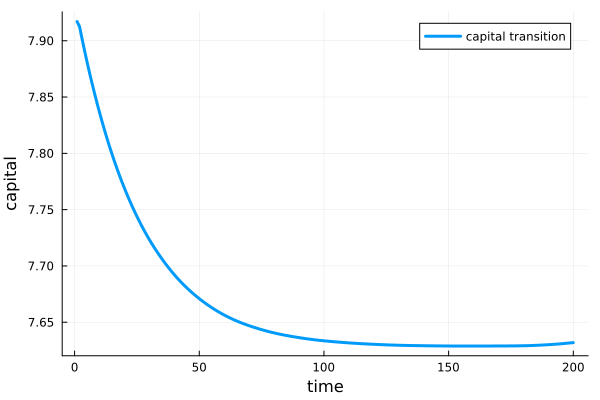

In [160]:
plot(1:NT, KT_transition, label="capital transition", linewidth=3)
xlabel!("time")
ylabel!("capital")

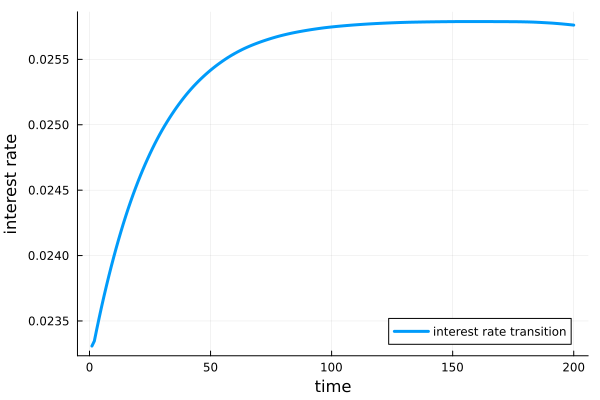

In [161]:
plot(1:NT, rT_transition, label="interest rate transition", linewidth=3)
xlabel!("time")
ylabel!("interest rate")

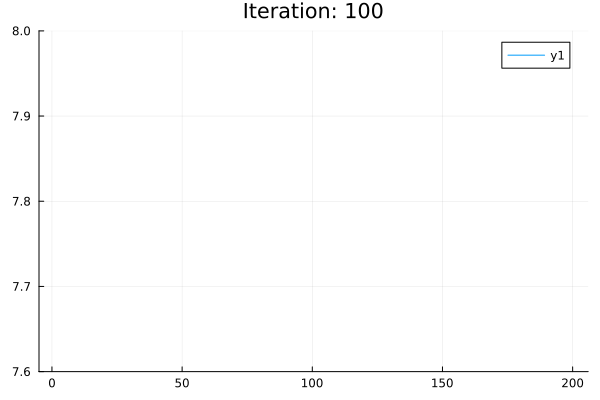

In [151]:
anim = Animation()
for i in 1:100
    current_plot = plot(1:NT, KT0_iteration_history[:, i], title="Iteration: $i")
    plot!(ylims=(7.6, 8.0))
    display(current_plot)
    sleep(0.10)
    frame(anim)
    IJulia.clear_output(true)
end

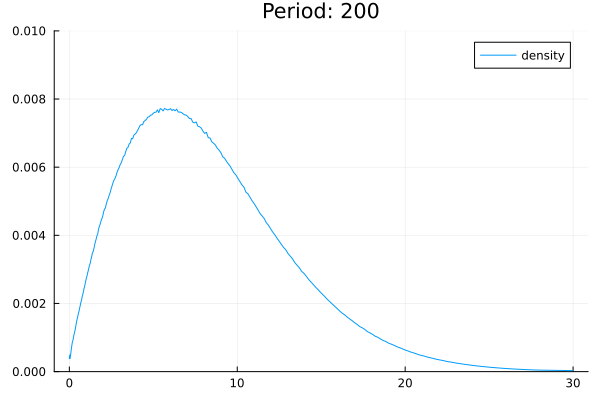

In [159]:
anim = Animation()
for i in 1:m.NT
    y = dropdims(sum(meaT[i, :, :], dims=1), dims=1)
    window = 20
    y_smooth = [mean(y[max(1,i-window÷2):min(length(y),i+window÷2)]) for i in 1:length(y)]
    current_plot = plot(grids[1], y_smooth, title="Period: $i", label="density", linewidth=1)
    ylims!(0, 0.01)
    display(current_plot)
    sleep(0.04)
    frame(anim)
    IJulia.clear_output(true)
end

In [168]:
# quantile of capital distribution
quantiles = [0.01, 0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
quantile_values = zeros(m.NT, length(quantiles))
for i in 1:m.NT
    y = dropdims(sum(meaT[i, :, :], dims=1), dims=1)
    cumulative = cumsum(y)
    for (j, q) in enumerate(quantiles)
        idx = findfirst(cumulative .>= q)
        quantile_values[i, j] = grids[1][idx]
    end
end

In [175]:
quantile_values

200×7 Matrix{Float64}:
 0.209729  1.83756  3.77043  6.95831  11.1153   15.5116  23.7434
 0.209729  1.83756  3.77043  6.862    10.9935   15.3676  23.5652
 0.209729  1.78824  3.77043  6.862    10.9935   15.2243  23.5652
 0.209729  1.78824  3.69962  6.862    10.8724   15.2243  23.3877
 0.209729  1.78824  3.69962  6.76637  10.7519   15.0817  23.2108
 0.193286  1.78824  3.69962  6.76637  10.7519   14.9398  23.2108
 0.193286  1.73958  3.62949  6.6714   10.6321   14.9398  23.0346
 0.193286  1.73958  3.62949  6.6714   10.6321   14.7985  22.8591
 0.193286  1.73958  3.62949  6.6714   10.513    14.7985  22.8591
 0.193286  1.73958  3.62949  6.57711  10.513    14.6579  22.6843
 0.193286  1.73958  3.56003  6.57711  10.3945   14.518   22.6843
 0.193286  1.69159  3.56003  6.57711  10.3945   14.518   22.5102
 0.193286  1.69159  3.56003  6.48348  10.2767   14.3787  22.5102
 ⋮                                               ⋮       
 0.134227  1.46173  3.09258  5.75866   9.1358   12.7599  20.1424
 0.134227

In [174]:
quantile_values[end, :] ./ quantile_values[1, :]

7-element Vector{Float64}:
 0.6399999999999998
 0.7954711468224981
 0.8202207191171236
 0.8275945216049382
 0.8319043593768867
 0.8310654407787994
 0.8483379501385041